# Object Detection with geowombat

This notebook walks through the geowombat object-detection module:

1. **Quickstart** — run a pretrained YOLO model on a public satellite
   detection benchmark (NWPU VHR-10 via TorchGeo) and score its accuracy.
2. **Geowombat-native workflow** — fetch a NAIP aerial image from
   Microsoft Planetary Computer plus OpenStreetMap building footprints,
   build a YOLO training dataset, run inference, score it, and export a
   GeoPackage you can review feature-by-feature in QGIS (e.g. with the
   GoToNextFeature3+ plugin).
3. **Optional fine-tuning** — fine-tune YOLO on the dataset built in
   step 2 so detections are actually useful for buildings.

Required installs:

```
pip install geowombat[dl,detect]
pip install pystac-client planetary-computer osmnx torchgeo
```

## Setup

In [1]:
import warnings
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

import geowombat as gw
from geowombat.ml.detection_data import (
    boxes_from_polygons,
    build_yolo_dataset,
)
from geowombat.ml.detection_metrics import (
    detection_accuracy,
    export_for_review,
    plot_detections,
)

warnings.filterwarnings('ignore')
WORK_DIR = Path('object_detection_demo')
WORK_DIR.mkdir(exist_ok=True)

## 1. Quickstart: pretrained YOLO on NWPU VHR-10

[NWPU VHR-10](https://gcheng-nwpu.github.io/) is a small (~715 images,
10 classes) public satellite-imagery detection benchmark. TorchGeo
auto-downloads it. We'll run a pretrained Ultralytics YOLO model on a
few images and score the result.

**Caveat:** YOLO's default weights are trained on COCO, which only
overlaps with VHR-10 on a couple of classes (e.g. *airplane*, *ship*,
*vehicle*). Expect low mAP — this section is about exercising the
API, not about state-of-the-art accuracy. The geowombat-native section
below shows the full train-and-score loop.

In [2]:
from torchgeo.datasets import VHR10

vhr_dir = WORK_DIR / 'vhr10'
ds = VHR10(root=str(vhr_dir), split='positive', download=True)
print(f'Dataset size: {len(ds)} positive images')
print('Classes:', ds.categories[:5], '...')

Files already downloaded and verified
loading annotations into memory...
Done (t=0.03s)
creating index...
index created!
Dataset size: 650 positive images
Classes: ('background', 'airplane', 'ships', 'storage tank', 'baseball diamond') ...


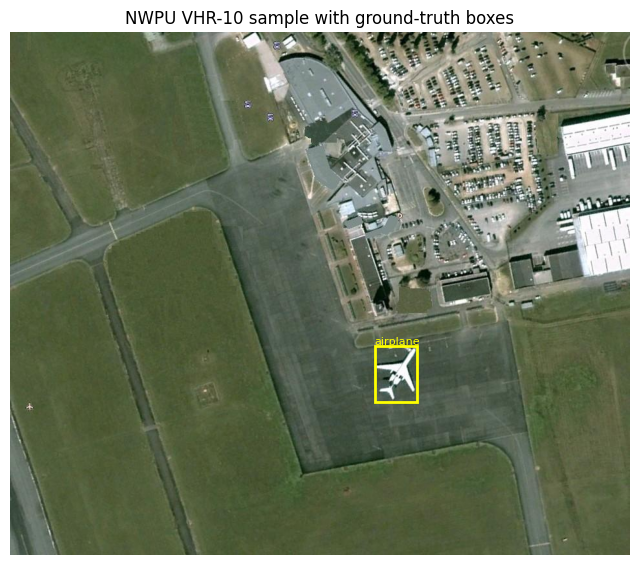

In [3]:
# Inspect a single sample. TorchGeo 0.9 keys: image, label, bbox_xyxy, mask
sample = ds[0]
img = sample['image'].permute(1, 2, 0).numpy().astype(np.uint8)
boxes = sample['bbox_xyxy'].numpy()
labels = sample['label'].numpy()

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(img)
for (x1, y1, x2, y2), lbl in zip(boxes, labels):
    ax.add_patch(plt.Rectangle((x1, y1), x2-x1, y2-y1,
                               fill=False, edgecolor='yellow', lw=2))
    ax.text(x1, y1-3, ds.categories[lbl], color='yellow', fontsize=8)
ax.set_title('NWPU VHR-10 sample with ground-truth boxes')
ax.axis('off')
plt.show()

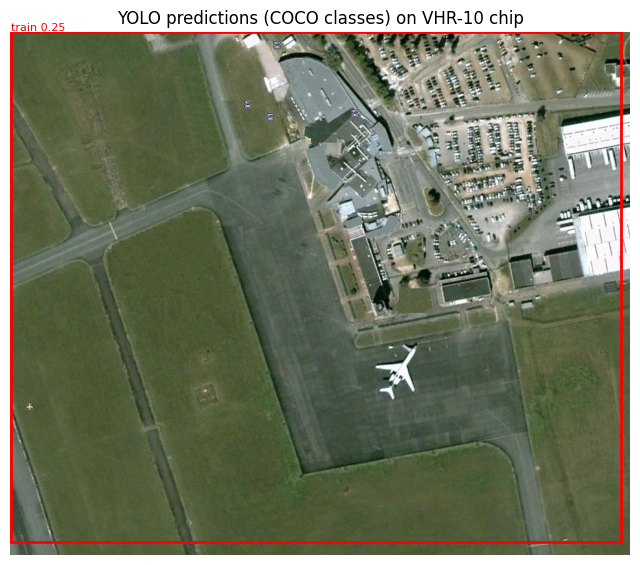

In [4]:
# Run pretrained YOLO directly on the chip — bypassing gw.open() since
# VHR-10 images are not georeferenced. We'll use the underlying
# ultralytics model directly here for simplicity.
from ultralytics import YOLO

yolo = YOLO('yolov8n.pt')
result = yolo.predict(source=img, conf=0.1, verbose=False)[0]

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(img)
if result.boxes is not None and len(result.boxes) > 0:
    for b, c, s in zip(result.boxes.xyxy.cpu().numpy(),
                       result.boxes.cls.cpu().numpy().astype(int),
                       result.boxes.conf.cpu().numpy()):
        x1, y1, x2, y2 = b
        ax.add_patch(plt.Rectangle((x1, y1), x2-x1, y2-y1,
                                    fill=False, edgecolor='red', lw=2))
        ax.text(x1, y1-3, f'{yolo.names[c]} {s:.2f}',
                color='red', fontsize=8)
ax.set_title('YOLO predictions (COCO classes) on VHR-10 chip')
ax.axis('off')
plt.show()

## 2. Geowombat-native workflow: NAIP + OpenStreetMap buildings

Now the full pipeline using a *georeferenced* raster and *georeferenced*
vector labels:

1. Pull a NAIP scene from Microsoft Planetary Computer for a small AOI.
2. Pull OSM building footprints for the same AOI with `osmnx`.
3. Build a YOLO-format training dataset with `build_yolo_dataset`.
4. Run inference; observe that COCO-pretrained YOLO won't see buildings.
5. Score with `detection_accuracy` and export a review GeoPackage.
6. Optional: fine-tune YOLO on the dataset from step 3.

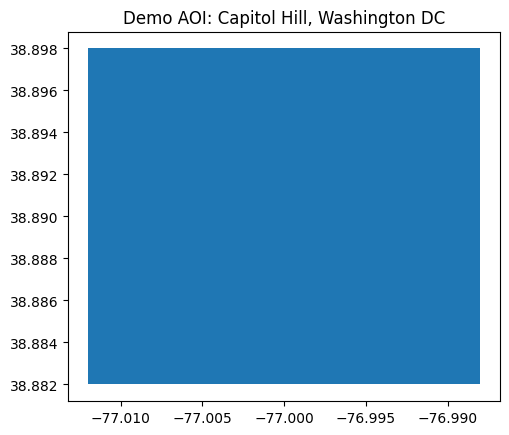

In [5]:
# AOI: ~2 km square over Capitol Hill, Washington DC. Row-house
# residential gives the fine-tune cell good signal (dense, regular,
# visually distinctive buildings). Adjust the bounds for any other
# city — wider bounds give more training data but a slower download.
from shapely.geometry import box as shapely_box

AOI_BOUNDS = (-77.012, 38.882, -76.988, 38.898)  # west, south, east, north
aoi = gpd.GeoDataFrame(
    {'name': ['demo']},
    geometry=[shapely_box(*AOI_BOUNDS)],
    crs='EPSG:4326',
)
aoi.plot()
plt.title('Demo AOI: Capitol Hill, Washington DC')
plt.show()

In [6]:
# Fetch a recent NAIP image via Planetary Computer STAC.
import pystac_client
import planetary_computer

catalog = pystac_client.Client.open(
    'https://planetarycomputer.microsoft.com/api/stac/v1',
    modifier=planetary_computer.sign_inplace,
)
search = catalog.search(
    collections=['naip'],
    bbox=AOI_BOUNDS,
    datetime='2021/2023',
)
items = list(search.items())
items.sort(key=lambda i: i.datetime, reverse=True)
item = items[0]
naip_url = item.assets['image'].href
print(f'NAIP scene: {item.id}  ({item.datetime.date()})')
print(f'URL: {naip_url[:80]}...')

NAIP scene: va_m_3807708_se_18_060_20231113_20240103  (2023-11-13)
URL: https://naipeuwest.blob.core.windows.net/naip/v002/va/2023/va_060cm_2023/38077/m...


In [7]:
# Fetch OSM building footprints for the AOI
import osmnx as ox

tags = {'building': True}
# osmnx 2.x: bbox is a single (left, bottom, right, top) tuple
buildings = ox.features_from_bbox(AOI_BOUNDS, tags=tags)
buildings = buildings[buildings.geometry.type.isin(['Polygon', 'MultiPolygon'])].copy()
buildings['class_name'] = 'building'
print(f'Fetched {len(buildings)} building footprints')
buildings.head(3)

Fetched 7944 building footprints


geometry addr:state  \
element  id                                                                     
relation 286501  POLYGON ((-77.00392 38.89077, -77.00375 38.890...         DC   
         286503  POLYGON ((-77.00614 38.88635, -77.00614 38.886...         DC   
         554408  POLYGON ((-77.00188 38.89778, -77.0019 38.8977...        NaN   

                   building  ele fixme gnis:feature_id  \
element  id                                              
relation 286501      office  NaN   NaN             NaN   
         286503  government  NaN   NaN             NaN   
         554408  apartments  NaN   NaN             NaN   

                                               name source  wikidata  \
element  id                                                            
relation 286501  Supreme Court of the United States    NaN    Q11201   
         286503        Cannon House Office Building    NaN  Q1033452   
         554408                                 NaN  dcgis       NaN   

                                             wikipedia  ...  dcgis:ssl  \
element  id                                             ...              
relation 286501  en:Supreme Court of the United States  ...  0728 0843   
         286503        en:Cannon House Office Building  ...  0690 0800   
         554408                                    NaN  ...        NaN   

                            dcgis:update_date                    name:br  \
element  id                                                                
relation 286501  Mon Mar 21 00:00:00 UTC 2005  Lez-veur ar Stadoù-Unanet   
         286503  Mon Mar 21 00:00:00 UTC 2005                        NaN   
         554408                           NaN                        NaN   

                year_of_construction name:etymology contact:flickr  \
element  id                                                          
relation 286501                 1935            NaN            NaN   
         286503                  NaN            NaN            NaN   
         554408                  NaN            NaN            NaN   

                contact:pinterest contact:twitter ref:isil class_name  
element  id                                                            
relation 286501               NaN             NaN      NaN   building  
         286503               NaN             NaN      NaN   building  
         554408               NaN             NaN      NaN   building  

[3 rows x 190 columns]

Wrote local AOI clip: object_detection_demo\naip_aoi.tif ((4, 3036, 2292))
Actual NAIP bounds (CRS units): (325480.7, 4305560.2, 326855.9, 4307381.8)
OSM buildings: 7944 fetched, 3971 inside actual raster footprint
NAIP scene: 3035 x 2292, 4 bands, 0.60 m


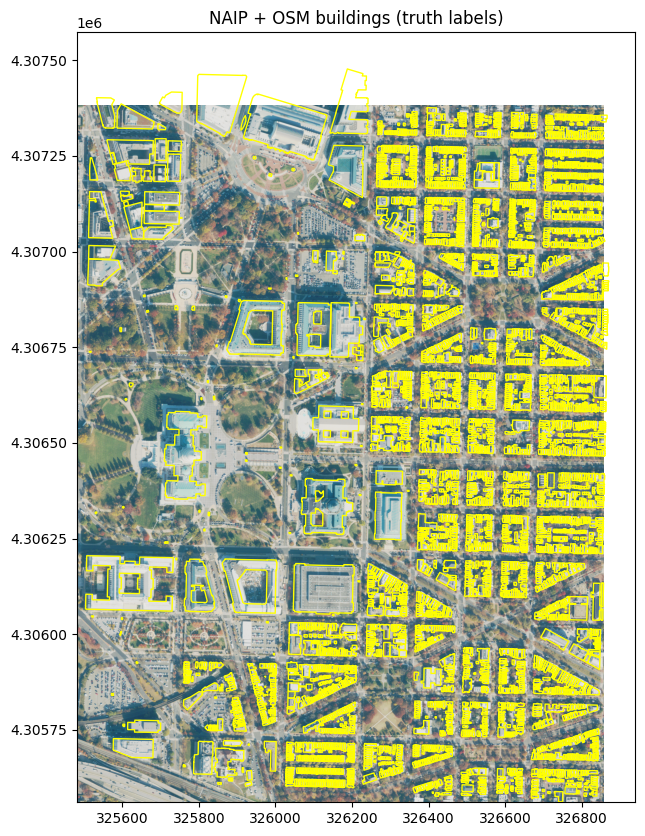

In [8]:
# Pre-download the AOI clip to a local TIF. Doing this once up front
# (a) avoids Planetary Computer SAS token expiry mid-notebook and
# (b) sidesteps gw.open()'s aversion to URLs with query strings.
import rasterio
from rasterio.warp import transform_bounds
from rasterio.windows import from_bounds

naip_local = WORK_DIR / 'naip_aoi.tif'
with rasterio.open(naip_url) as ds_meta:
    naip_crs = ds_meta.crs
    aoi_in_naip_crs = transform_bounds('EPSG:4326', naip_crs, *AOI_BOUNDS)
    window = from_bounds(*aoi_in_naip_crs, transform=ds_meta.transform)
    arr = ds_meta.read(window=window)
    profile = ds_meta.profile.copy()
    profile.update({
        'height': arr.shape[1],
        'width': arr.shape[2],
        'transform': ds_meta.window_transform(window),
        'driver': 'GTiff',
    })
    with rasterio.open(naip_local, 'w', **profile) as dst:
        dst.write(arr)
print(f'Wrote local AOI clip: {naip_local} ({arr.shape})')

# Read the *actual* bounds from the saved file. NAIP COG tiles often
# don't cover the full requested AOI, so the on-disk raster is
# smaller than what we asked for. Without clipping OSM truth to the
# real extent, features that lie off the raster count as false
# negatives — the detector can't possibly see them.
with rasterio.open(naip_local) as ds_actual:
    actual_naip_bounds = ds_actual.bounds
print(f'Actual NAIP bounds (CRS units): {tuple(round(b, 1) for b in actual_naip_bounds)}')

buildings_proj = buildings.to_crs(naip_crs)
n_total = len(buildings_proj)
naip_footprint = shapely_box(*actual_naip_bounds)
buildings_proj = buildings_proj[
    buildings_proj.intersects(naip_footprint)
].copy()
print(f'OSM buildings: {n_total} fetched, '
      f'{len(buildings_proj)} inside actual raster footprint')

with gw.open(naip_local, chunks=512) as src:
    print(f'NAIP scene: {src.gw.nrows} x {src.gw.ncols}, '
          f'{src.gw.nbands} bands, {src.gw.cellx:.2f} m')
    fig, ax = plt.subplots(figsize=(10, 10))
    rgb = src.isel(band=slice(0, 3)).values.transpose(1, 2, 0)
    rgb = rgb.astype(np.uint8)  # NAIP is already uint8
    ax.imshow(rgb, extent=(src.gw.left, src.gw.right,
                           src.gw.bottom, src.gw.top))
    buildings_proj.boundary.plot(ax=ax, color='yellow', lw=1)
    ax.set_title('NAIP + OSM buildings (truth labels)')
    plt.show()

In [9]:
# Build a YOLO-format training dataset from the NAIP raster + buildings.
# Bands 0,1,2 of NAIP are R,G,B and already 8-bit, so no scaling needed.
yolo_dir = WORK_DIR / 'naip_buildings_yolo'

with gw.open(naip_local, chunks=512) as src:
    info = build_yolo_dataset(
        src,
        labels=buildings_proj,
        class_col='class_name',
        out_dir=yolo_dir,
        tile_size=640,
        overlap=0.1,
        val_split=0.2,
        min_box_pixels=10,
        background_ratio=0.1,
        band_indices=[0, 1, 2],
        scale=None,  # NAIP is already uint8 RGB
    )
print(info)

{'out_dir': 'object_detection_demo\\naip_buildings_yolo', 'classes': ['building'], 'n_train': 17, 'n_val': 7, 'n_boxes': 2647, 'empty_kept': 0, 'empty_skipped': 0}


### Inference with pretrained YOLO

We run `YOLODetector` directly on the NAIP scene. Pretrained COCO
weights have no 'building' class, so we expect very few or no useful
detections — but this verifies the inference pipeline (tile windowing,
cross-tile NMS, pixel→CRS box conversion) end-to-end.

In [10]:
from geowombat.ml.detectors import YOLODetector

det = YOLODetector(weights='yolov8n.pt')

with gw.open(naip_local, chunks=512) as src:
    preds = det.predict(
        src,
        tile_size=640,
        overlap=0.2,
        conf=0.10,        # low threshold since COCO != buildings
        band_indices=[0, 1, 2],
        scale=None,
        nms_iou=0.5,
        progress=True,
    )
print(f'{len(preds)} detections from pretrained YOLO')
preds.head()

YOLODetector:   0%|          | 0/30 [00:00<?, ?it/s]

YOLODetector:   3%|▎         | 1/30 [00:00<00:05,  5.01it/s]

YOLODetector:   7%|▋         | 2/30 [00:00<00:04,  6.17it/s]

YOLODetector:  10%|█         | 3/30 [00:00<00:04,  6.60it/s]

YOLODetector:  13%|█▎        | 4/30 [00:00<00:03,  7.30it/s]

...

YOLODetector:  93%|█████████▎| 28/30 [00:03<00:00,  8.95it/s]

YOLODetector:  97%|█████████▋| 29/30 [00:03<00:00,  9.04it/s]

YOLODetector: 100%|██████████| 30/30 [00:03<00:00,  8.40it/s]

37 detections from pretrained YOLO


,geometry,class_id,class_name,score,tile_id
0,"POLYGON ((325844.105 4305685.203, 325844.105 4...",74,clock,0.586726,25
1,"POLYGON ((326167.441 4306312.821, 326167.441 4...",74,clock,0.552429,17
2,"POLYGON ((326501.741 4306098.305, 326501.741 4...",9,traffic light,0.444301,24
3,"POLYGON ((325793.735 4306443.675, 325793.735 4...",9,traffic light,0.339263,10
4,"POLYGON ((325843.113 4305666.328, 325843.113 4...",74,clock,0.307150,25


### Reading the accuracy output

Before we compute metrics, a quick glossary — these terms appear in the
tables below and in the per-feature `status` column of the review
GeoPackage.

**Per-detection / per-truth labels**

- **TP — True Positive.** A predicted box that overlaps a ground-truth
  box with IoU ≥ the threshold *and* has the correct class. A hit.
- **FP — False Positive.** A predicted box with no matching truth at
  the chosen IoU. A hallucination.
- **FP_class — Wrong-class False Positive.** Predicted box landed in
  about the right place (IoU ≥ threshold against *some* truth) but the
  class label was wrong. Useful to separate 'model can't see it' from
  'model sees it but mislabels it'.
- **FN — False Negative.** A ground-truth box no detection matched.
  A miss.

**IoU — Intersection over Union.** The area of overlap divided by the
area of union between two boxes. 1.0 = perfect overlap, 0.0 = no
overlap. The IoU threshold (`0.3`, `0.5`, …) controls how strict the
spatial agreement needs to be to count as a match. 0.5 is the standard
PASCAL VOC threshold; 0.3 is more lenient and useful for noisy or very
small targets.

**Aggregate metrics**

- **precision = TP / (TP + FP)** — of what the model predicted, what
  fraction was right? Penalizes false alarms.
- **recall = TP / (TP + FN)** — of all the real objects, what fraction
  did the model find? Penalizes misses.
- **F1 = 2 · (precision · recall) / (precision + recall)** — harmonic
  mean of the two; one number that drops if either side is poor.
- **AP — Average Precision.** Sweeps the confidence threshold from
  high to low and integrates the precision-recall curve. A single
  per-class number that captures the precision/recall tradeoff over
  all confidence levels.
- **mAP@0.5** — the mean of per-class AP at IoU ≥ 0.5. The standard
  single-number summary for a detector.
- **mAP@\[.5:.95]** — average of mAP at IoU thresholds 0.5, 0.55, …,
  0.95. COCO's stricter measure; rewards tightly localized boxes.
- **support** — number of ground-truth boxes for that class (the
  denominator for recall). Small support = noisy estimate.

Higher is better for everything except the bucket counts (where higher
is better only for TP).

In [11]:
# Accuracy assessment vs. OSM truth. We re-tag predictions as 'building'
# so the comparison is meaningful — pretrained YOLO labels things
# 'car', 'truck', etc., but we just want to see what it *boxed*.
preds_as_building = preds.copy()
preds_as_building['class_name'] = 'building'

results_pretrained = detection_accuracy(
    predictions=preds_as_building,
    truth=buildings_proj[['class_name', 'geometry']],
    class_col='class_name',
    iou_thresholds=(0.3, 0.5),
)
print('Per-class metrics (pretrained YOLO, no fine-tuning):')
print(results_pretrained['metrics'])
print()
print('Summary:', results_pretrained['summary'])
results = results_pretrained  # alias kept for the cells below

Per-class metrics (pretrained YOLO, no fine-tuning):
                              ap  precision    recall        f1  tp  fp    fn  \
iou_threshold class                                                             
0.3           building  0.018182   0.108108  0.001007  0.001996   4  33  3967   
0.5           building  0.018182   0.081081  0.000755  0.001497   3  34  3968   

                        support  
iou_threshold class              
0.3           building     3971  
0.5           building     3971  

Summary: {'mAP@0.3': 0.018181818181818184, 'mAP@0.5': 0.018181818181818184}


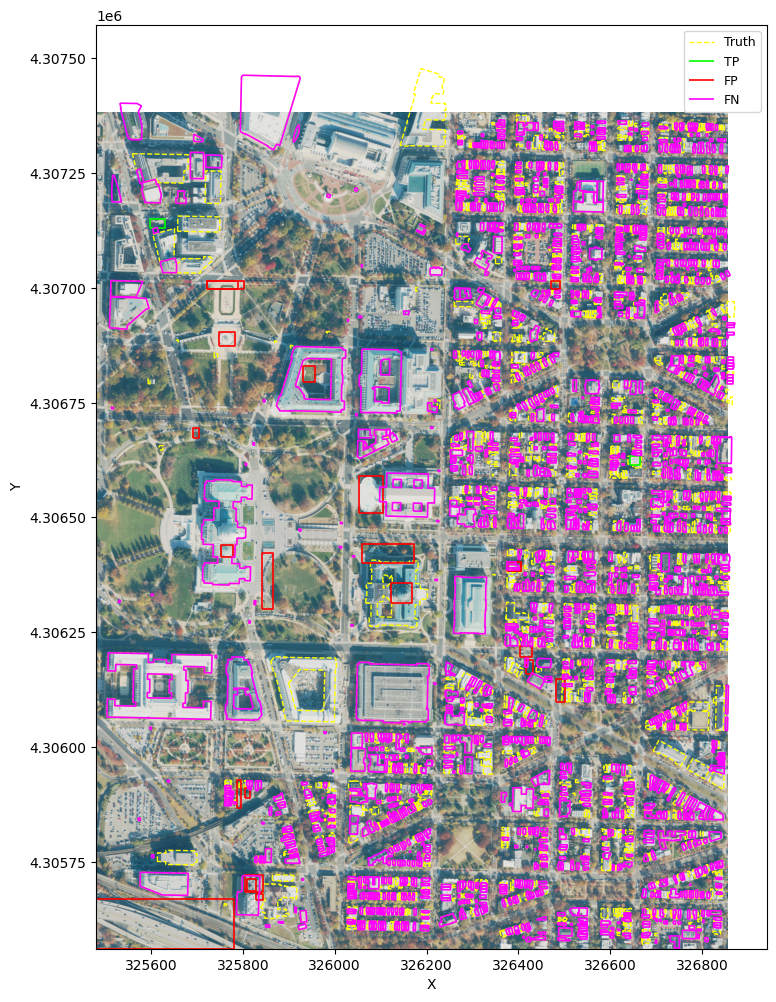

In [12]:
# Visualize TP / FP / FN
with gw.open(naip_local, chunks=512) as src:
    fig, ax = plt.subplots(figsize=(12, 12))
    plot_detections(
        src,
        predictions=results['matched'],
        truth=buildings_proj,
        ax=ax,
        band_indices=[0, 1, 2],
        scale=None,
    )
    plt.show()

In [13]:
# Export the review GeoPackage. Open this in QGIS, use the attribute
# form or GoToNextFeature3+ to step through each detection, and fill in
# `reviewer_label` (TP/FP/FN/unclear). Then call recompute_from_review.
review_path = WORK_DIR / 'review.gpkg'
export_for_review(results['matched'], review_path)
print(f'Review file: {review_path.resolve()}')
print('  In QGIS: Open layer → switch to Form view → use',
      '"GoToNextFeature3+" or built-in next-feature shortcut.')

Review file: C:\Users\mmann1123\Documents\github\geowombat\notebooks\object_detection_demo\review.gpkg
  In QGIS: Open layer → switch to Form view → use "GoToNextFeature3+" or built-in next-feature shortcut.


## 3. Fine-tune YOLO on the building dataset

Pretrained COCO YOLO can't recognize buildings. Fine-tuning teaches
it to. We train `yolov8n` (the smallest variant, ~3M parameters) on
the dataset we just built. Settings chosen for CPU-friendliness:
small `imgsz`, small `batch`, modest `epochs`. On a typical laptop
CPU expect a few minutes total; on GPU, well under one minute.

We send Ultralytics' `runs/` output into `WORK_DIR` so the demo
leaves no clutter at the repo root.

In [14]:
from ultralytics import YOLO

yolo_train = YOLO('yolov8n.pt')
_ = yolo_train.train(
    data=str(yolo_dir.resolve() / 'data.yaml'),
    epochs=15,
    imgsz=416,
    batch=4,
    name='gw_buildings',
    exist_ok=True,
    verbose=False,
    plots=False,
)

# Ultralytics writes runs/ relative to its own cwd regardless of the
# project= kwarg, so we read the actual save_dir from the trainer.
best_weights = Path(yolo_train.trainer.save_dir) / 'weights' / 'best.pt'
print(f'Best weights: {best_weights}')
print(f'Exists: {best_weights.exists()}')

Ultralytics 8.4.51  Python-3.12.10 torch-2.12.0+cpu CPU (Intel Xeon W-2135 CPU @ 3.70GHz)


engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\mmann1123\Documents\github\geowombat\notebooks\object_detection_demo\naip_buildings_yolo\data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=gw_buildings, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, 

Overriding model.yaml nc=80 with nc=1



                   from  n    params  module                                       arguments                     


  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 


...

Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 2.9it/s 0.3s

                   all          7        661     0.0748      0.238     0.0475     0.0152


Speed: 0.4ms preprocess, 29.0ms inference, 0.0ms loss, 11.9ms postprocess per image


Best weights: C:\Users\mmann1123\Documents\github\geowombat\runs\detect\gw_buildings\weights\best.pt
Exists: True


### Re-run inference with the fine-tuned model

Same `YOLODetector` API, just point it at our new weights. We use a
low confidence threshold (`0.05`) because with only ~17 training tiles
and 15 epochs the model is heavily under-trained and hesitant —
production weights would justify a much higher threshold like `0.25`.

The point of this section is to show the *fine-tuning pipeline* works
end-to-end. The numbers themselves will improve substantially with
more data (a wider AOI), more epochs (50–100), and a larger backbone
(`yolov8s.pt` or `yolov8m.pt`).

In [15]:
det_ft = YOLODetector(
    weights=str(best_weights),
    classes=['building'],
)

with gw.open(naip_local, chunks=512) as src:
    preds_ft = det_ft.predict(
        src,
        tile_size=416,           # match the size we trained at
        overlap=0.2,
        conf=0.05,               # under-trained model needs low conf
        band_indices=[0, 1, 2],
        scale=None,
        nms_iou=0.5,
        progress=True,
    )
print(f'{len(preds_ft)} detections from fine-tuned YOLO',
      f'(was {len(preds)} pretrained)')

YOLODetector:   0%|          | 0/63 [00:00<?, ?it/s]

YOLODetector:   2%|▏         | 1/63 [00:00<00:08,  7.06it/s]

YOLODetector:   5%|▍         | 3/63 [00:00<00:06,  9.87it/s]

YOLODetector:   8%|▊         | 5/63 [00:00<00:05, 10.42it/s]

YOLODetector:  11%|█         | 7/63 [00:00<00:05, 10.90it/s]

...

YOLODetector:  94%|█████████▎| 59/63 [00:05<00:00, 10.44it/s]

YOLODetector:  97%|█████████▋| 61/63 [00:05<00:00, 10.87it/s]

YOLODetector: 100%|██████████| 63/63 [00:05<00:00, 11.86it/s]

YOLODetector: 100%|██████████| 63/63 [00:05<00:00, 11.34it/s]

128 detections from fine-tuned YOLO (was 37 pretrained)


In [16]:
# Score the fine-tuned predictions
results_ft = detection_accuracy(
    predictions=preds_ft,
    truth=buildings_proj[['class_name', 'geometry']],
    class_col='class_name',
    iou_thresholds=(0.3, 0.5),
)
print('Per-class metrics (fine-tuned YOLO):')
print(results_ft['metrics'])
print()
print('Summary:', results_ft['summary'])

Per-class metrics (fine-tuned YOLO):
                              ap  precision    recall        f1  tp  fp    fn  \
iou_threshold class                                                             
0.3           building  0.090909   0.585938  0.018887  0.036594  75  53  3896   
0.5           building  0.060606   0.343750  0.011080  0.021469  44  84  3927   

                        support  
iou_threshold class              
0.3           building     3971  
0.5           building     3971  

Summary: {'mAP@0.3': 0.09090909090909091, 'mAP@0.5': 0.0606060606060606}


### Before vs. after

Side-by-side comparison of the pretrained and fine-tuned runs at
IoU ≥ 0.3. Look at TP/FN going up/down for recall and FP for
precision — the F1 column is the single-number summary.

In [17]:
import pandas as pd

iou = 0.3  # use the more lenient threshold for the comparison
row_pre = results_pretrained['metrics'].loc[(iou, 'building')]
row_ft = results_ft['metrics'].loc[(iou, 'building')]
compare = pd.DataFrame(
    {'pretrained': row_pre, 'fine-tuned': row_ft},
)
compare['delta'] = compare['fine-tuned'] - compare['pretrained']
print(f'Comparison at IoU >= {iou}:')
print(compare.round(3))

Comparison at IoU >= 0.3:
           pretrained  fine-tuned   delta
ap              0.018       0.091   0.073
precision       0.108       0.586   0.478
recall          0.001       0.019   0.018
f1              0.002       0.037   0.035
tp              4.000      75.000  71.000
fp             33.000      53.000  20.000
fn           3967.000    3896.000 -71.000
support      3971.000    3971.000   0.000


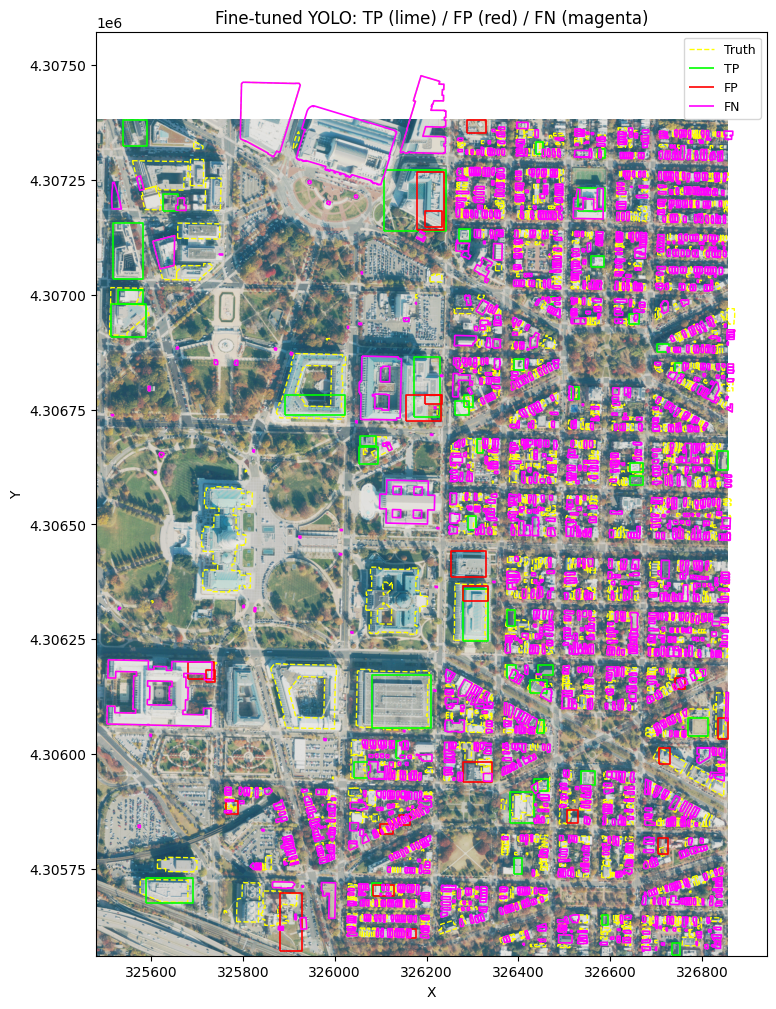

In [18]:
# Visualize TP / FP / FN from the fine-tuned run
with gw.open(naip_local, chunks=512) as src:
    fig, ax = plt.subplots(figsize=(12, 12))
    plot_detections(
        src,
        predictions=results_ft['matched'],
        truth=buildings_proj,
        ax=ax,
        band_indices=[0, 1, 2],
        scale=None,
    )
    ax.set_title('Fine-tuned YOLO: TP (lime) / FP (red) / FN (magenta)')
    plt.show()

## Summary

- `build_yolo_dataset` turns a `gw.open()`'d raster + label GeoDataFrame
  into a YOLO-format training corpus on disk.
- `YOLODetector` and `TorchGeoDetector` produce georeferenced
  `GeoDataFrame` outputs from tiled, windowed inference with cross-tile
  NMS.
- `SAMRefiner` (requires `geowombat[sam]`) refines bounding-box outputs
  to polygon masks using the box as a SAM prompt.
- `detection_accuracy` computes per-class precision/recall/F1/AP at one
  or more IoU thresholds and returns a *review-ready* GeoDataFrame.
- `export_for_review` writes a GeoPackage for QGIS attribute-form
  review; `recompute_from_review` recomputes metrics after a human has
  labeled the review file.